In [49]:
import pandas as pd
import numpy as np

# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "creditcard.csv"

# Load the latest version
df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
  "mlg-ulb/creditcardfraud",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:")
print(df.head())
print(df.shape)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
First 5 records:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ...

In [50]:
print('Missing values:', df.isnull().sum().sum())
print('\nDtypes:\n', df.dtypes.value_counts())

Missing values: 0

Dtypes:
 float64    30
int64       1
Name: count, dtype: int64


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [52]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


In [53]:
df['Class'].value_counts(normalize=True)

,proportion
Class,
0,0.998273
1,0.001727


In [54]:
df[['Amount', 'Class']].groupby('Class').mean()

,Amount
Class,
0,88.291022
1,122.211321


In [55]:
print("\n" + "-"*80)
print("Statistical Summary:")
print("-"*80)
print(df.describe())


--------------------------------------------------------------------------------
Statistical Summary:
--------------------------------------------------------------------------------
                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e

# DataPreprocessing

<Axes: >

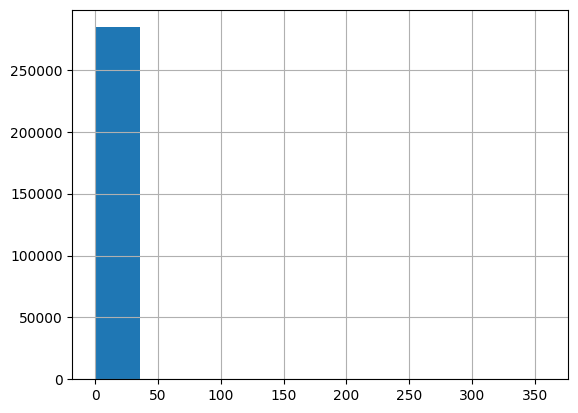

In [56]:
#Amount ranges from 0 to 25691.160000

from sklearn.preprocessing import RobustScaler, StandardScaler
new_df = df.copy()
new_df['Amount'] = RobustScaler().fit_transform(new_df['Amount'].to_numpy().reshape(-1, 1))
new_df['Amount'].hist()

In [57]:
new_df['Amount'].describe()

,Amount
count,284807.000000
mean,0.927124
std,3.495006
min,-0.307413
25%,-0.229162
50%,0.000000
75%,0.770838
max,358.683155


In [58]:
time = new_df['Time']
#standard scaler
new_df['Time'] = StandardScaler().fit_transform(new_df[['Time']])
new_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.996583,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,1.783274,0
1,-1.996583,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.269825,0
2,-1.996562,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,4.983721,0
3,-1.996562,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,1.418291,0
4,-1.996541,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0.670579,0


In [59]:
new_df = new_df.sample(frac=1, random_state=42)
new_df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
43428,-1.122574,-16.526507,8.584972,-18.649853,9.505594,-13.793819,-2.832404,-16.701694,7.517344,-8.507059,...,1.190739,-1.127670,-2.358579,0.673461,-1.413700,-0.462762,-2.018575,-1.042804,4.781527,1
49906,-1.064538,0.339812,-2.743745,-0.134070,-1.385729,-1.451413,1.015887,-0.524379,0.224060,0.899746,...,-0.213436,-0.942525,-0.526819,-1.156992,0.311211,-0.746647,0.040996,0.102038,6.960386,0
29474,-1.249364,1.399590,-0.590701,0.168619,-1.029950,-0.539806,0.040444,-0.712567,0.002299,-0.971747,...,0.102398,0.168269,-0.166639,-0.810250,0.505083,-0.232340,0.011409,0.004634,0.125760,0
276481,1.522680,-0.432071,1.647895,-1.669361,-0.349504,0.785785,-0.630647,0.276990,0.586025,-0.484715,...,0.358932,0.873663,-0.178642,-0.017171,-0.207392,-0.157756,-0.237386,0.001934,-0.286453,0
278846,1.551109,2.014160,-0.137394,-1.015839,0.327269,-0.182179,-0.956571,0.043241,-0.160746,0.363241,...,-0.238644,-0.616400,0.347045,0.061561,-0.360196,0.174730,-0.078043,-0.070571,-0.294977,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119879,-0.404225,1.173488,0.100792,0.490512,0.461596,-0.296377,-0.213165,-0.165254,0.119221,-0.114199,...,-0.186027,-0.574283,0.161405,-0.006140,0.091444,0.109235,-0.020922,0.003967,-0.279746,0
259178,1.351627,-0.775981,0.144023,-1.142399,-1.241113,1.940358,3.912076,-0.466107,1.360620,0.400697,...,0.037078,-0.019575,0.241830,0.682820,-1.635109,-0.770941,0.066006,0.137056,0.939426,0
131932,-0.316266,-0.146609,0.992946,1.524591,0.485774,0.349308,-0.815198,1.076640,-0.395316,-0.491303,...,0.052649,0.354089,-0.291198,0.402849,0.237383,-0.398467,-0.121139,-0.196195,-0.252358,0
146867,-0.144939,-2.948638,2.354849,-2.521201,-3.798905,1.866302,2.727695,-0.471769,2.217537,0.580199,...,-0.332759,-1.047514,0.143326,0.678869,0.319710,0.426309,0.496912,0.335822,-0.293440,0


In [60]:
from sklearn.model_selection import train_test_split

train, temp = train_test_split(
    new_df,
    test_size=0.2,
    stratify=new_df['Class'],
    random_state=42
)

test, val = train_test_split(
    temp,
    test_size=0.5,
    stratify=temp['Class'],
    random_state=42
)

In [61]:
x_train = train.drop(columns=['Class'])
y_train = train['Class']

x_test = test.drop(columns=['Class'])
y_test = test['Class']

x_val = val.drop(columns=['Class'])
y_val = val['Class']

x_train.shape, y_train.shape, x_test.shape, y_test.shape, x_val.shape, y_val.shape

((227845, 30), (227845,), (28481, 30), (28481,), (28481, 30), (28481,))

# XGBoost

In [62]:
pip install xgboost

In [63]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos

In [64]:
from xgboost import XGBClassifier

# Calculate pos_weight using the already defined neg and pos counts
pos_weight = neg / pos

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    scale_pos_weight=pos_weight,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(x_train, y_train)

# Validation predictions
y_pred = xgb.predict(x_val)
y_proba = xgb.predict_proba(x_val)[:, 1]


In [65]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_val, y_proba)
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9548654577193849


In [66]:
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score, precision_score, recall_score, f1_score
print(confusion_matrix(y_val, y_pred))
print(classification_report(y_val, y_pred))
pr_auc = average_precision_score(y_val, y_proba)
print("Validation PR-AUC:", pr_auc)

print("Overall Precision:", precision_score(y_val, y_pred, average='weighted'))
print("Overall Recall:", recall_score(y_val, y_pred, average='weighted'))
print("Overall F1 Score:", f1_score(y_val, y_pred, average='weighted'))

[[28421    11]
 [    9    40]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28432
           1       0.78      0.82      0.80        49

    accuracy                           1.00     28481
   macro avg       0.89      0.91      0.90     28481
weighted avg       1.00      1.00      1.00     28481

Validation PR-AUC: 0.8055327186066918
Overall Precision: 0.9993129012118609
Overall Recall: 0.9992977774656788
Overall F1 Score: 0.9993047873414295


Due to the extreme class imbalance in credit card fraud detection, Precision–Recall AUC is used as the primary evaluation metric. Unlike ROC-AUC, which can remain high even with many false positives, PR-AUC more accurately reflects the model’s ability to detect rare fraudulent transactions while maintaining precision.

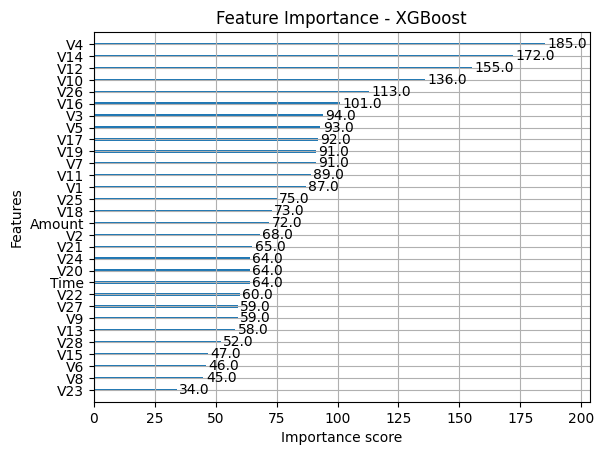

In [67]:
import matplotlib.pyplot as plt
from xgboost import plot_importance
plot_importance(xgb)
plt.title("Feature Importance - XGBoost")
plt.show()

The feature importance plot shows which variables most influenced the fraud detection model. XGBoost prioritizes features that contribute most to reducing prediction error, and the results indicate that a few key variables dominate the decision process.

cross-validation

In [68]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    xgb,
    x_train,
    y_train,
    cv=5,
    scoring="average_precision"
)

print("Cross-validated PR-AUC:", cv_scores.mean())

Cross-validated PR-AUC: 0.8427206802418775


Cross-validation was performed using PR-AUC (average precision) as the scoring metric because the dataset is highly imbalanced. The model achieved a mean cross-validated PR-AUC of 0.84, indicating strong ability to identify fraudulent transactions.

# Hyperparameter Tuning for XGBoost

In [69]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators":[100,200,300],
    "max_depth":[3,4,6,8],
    "learning_rate":[0.01,0.05,0.1],
    "subsample":[0.8,1],
    "colsample_bytree":[0.8,1]
}

search = RandomizedSearchCV(
    XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42
    ),
    param_distributions=param_dist,
    n_iter=10,
    scoring="average_precision",
    cv=3,
    n_jobs=-1,
    random_state=42
)

search.fit(x_train, y_train)

print("Best PR-AUC:", search.best_score_)
print("Best Params:", search.best_params_)

Best PR-AUC: 0.8600115121855771
Best Params: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


In [70]:
best_xgb = search.best_estimator_

feature_importance = pd.DataFrame({
    'feature': x_train.columns,
    'importance': best_xgb.feature_importances_
}).sort_values('importance', ascending=False)

top20_features = feature_importance.head(20)['feature'].tolist()
top15_features = feature_importance.head(15)['feature'].tolist()
top10_features = feature_importance.head(10)['feature'].tolist()

print("Top 10 features:", top10_features)

Top 10 features: ['V14', 'V12', 'V4', 'V10', 'V17', 'V20', 'V8', 'Amount', 'V7', 'V19']


In [71]:
feature_importance = pd.DataFrame({
    'feature': x_train.columns,
    'importance': best_xgb.feature_importances_
}).sort_values('importance', ascending=False)

top20_features = feature_importance.head(20)['feature'].tolist()
top15_features = feature_importance.head(15)['feature'].tolist()
top10_features = feature_importance.head(10)['feature'].tolist()

print("Top 20 Features:", top20_features)
print("Top 15 Features:", top15_features)
print("Top 10 Features:", top10_features)

Top 20 Features: ['V14', 'V12', 'V4', 'V10', 'V17', 'V20', 'V8', 'Amount', 'V7', 'V19', 'V3', 'V13', 'V15', 'V11', 'V25', 'V18', 'V23', 'V21', 'V6', 'Time']
Top 15 Features: ['V14', 'V12', 'V4', 'V10', 'V17', 'V20', 'V8', 'Amount', 'V7', 'V19', 'V3', 'V13', 'V15', 'V11', 'V25']
Top 10 Features: ['V14', 'V12', 'V4', 'V10', 'V17', 'V20', 'V8', 'Amount', 'V7', 'V19']


Top 20 features section

In [72]:
from sklearn.metrics import confusion_matrix, classification_report
from xgboost import XGBClassifier

model20 = XGBClassifier(**search.best_params_)

model20.fit(x_train[top20_features], y_train)

probs20 = model20.predict_proba(x_val[top20_features])[:,1]

threshold = 0.7
preds20 = (probs20 >= threshold).astype(int)

print("Results for Top 20 Features")
print(confusion_matrix(y_val, preds20))
print(classification_report(y_val, preds20))

Results for Top 20 Features
[[28431     1]
 [   12    37]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28432
           1       0.97      0.76      0.85        49

    accuracy                           1.00     28481
   macro avg       0.99      0.88      0.93     28481
weighted avg       1.00      1.00      1.00     28481



Top 15 features section

In [73]:
model15 = XGBClassifier(**search.best_params_)

model15.fit(x_train[top15_features], y_train)

probs15 = model15.predict_proba(x_val[top15_features])[:,1]

threshold = 0.7
preds15 = (probs15 >= threshold).astype(int)

print("Results for Top 15 Features")
print(confusion_matrix(y_val, preds15))
print(classification_report(y_val, preds15))

Results for Top 15 Features
[[28430     2]
 [   10    39]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28432
           1       0.95      0.80      0.87        49

    accuracy                           1.00     28481
   macro avg       0.98      0.90      0.93     28481
weighted avg       1.00      1.00      1.00     28481



Top 10 features section

In [74]:
model10 = XGBClassifier(**search.best_params_)

model10.fit(x_train[top10_features], y_train)

probs10 = model10.predict_proba(x_val[top10_features])[:,1]

threshold = 0.7
preds10 = (probs10 >= threshold).astype(int)

print("Results for Top 10 Features")
print(confusion_matrix(y_val, preds10))
print(classification_report(y_val, preds10))

Results for Top 10 Features
[[28429     3]
 [   15    34]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28432
           1       0.92      0.69      0.79        49

    accuracy                           1.00     28481
   macro avg       0.96      0.85      0.90     28481
weighted avg       1.00      1.00      1.00     28481



Evaluate Tuned XGBoost Model on Validation Set

In [75]:
best_xgb = search.best_estimator_

best_xgb.fit(x_train, y_train)

y_pred = best_xgb.predict(x_val)
y_proba = best_xgb.predict_proba(x_val)[:,1]

from sklearn.metrics import average_precision_score
print("Validation PR-AUC:", average_precision_score(y_val, y_proba))
print(classification_report(y_val, y_pred))

Validation PR-AUC: 0.829460523176265
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28432
           1       0.87      0.80      0.83        49

    accuracy                           1.00     28481
   macro avg       0.93      0.90      0.91     28481
weighted avg       1.00      1.00      1.00     28481



In [76]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_val, y_proba)

In [77]:
f1 = 2 * precision * recall / (precision + recall + 1e-9)
best_idx = np.argmax(f1)
best_threshold = thresholds[best_idx]

print("Best threshold:", best_threshold)

y_pred = (y_proba >= best_threshold).astype(int)

print(classification_report(y_val, y_pred))

pr_auc = average_precision_score(y_val, y_proba)
print("PR-AUC after threshold tuning:", pr_auc)


Best threshold: 0.92449063
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28432
           1       0.93      0.78      0.84        49

    accuracy                           1.00     28481
   macro avg       0.96      0.89      0.92     28481
weighted avg       1.00      1.00      1.00     28481

PR-AUC after threshold tuning: 0.829460523176265


Hyperparameter tuning improved cross-validated PR-AUC to 0.86.
The tuned model achieved 0.829 PR-AUC on the validation set, indicating strong generalization performance for fraud detection.

SMOTE

In [78]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import average_precision_score

smote_pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("xgb", XGBClassifier(
        eval_metric="logloss",
        random_state=42
    ))
])

smote_pipeline.fit(x_train, y_train)

y_pred_smote = smote_pipeline.predict(x_val)
y_proba_smote = smote_pipeline.predict_proba(x_val)[:,1]

print("SMOTE Validation PR-AUC:",
      average_precision_score(y_val, y_proba_smote))

SMOTE Validation PR-AUC: 0.813250382087734


An experiment was conducted using SMOTE to handle class imbalance. The model trained with SMOTE achieved a validation PR-AUC of 0.813, which is slightly lower than the tuned XGBoost model that used scale_pos_weight, which achieved a validation PR-AUC of 0.829. Therefore, the scale_pos_weight approach was selected as the final model for fraud detection.

In [79]:
from sklearn.metrics import precision_recall_curve, classification_report
import numpy as np

#Threshold tuning the XGBoost Model
precision, recall, thresholds = precision_recall_curve(y_val, y_proba)

#choose threshold that maximizes F1
f1 = 2 * (precision * recall) / (precision + recall + 1e-9)
best_idx = np.argmax(f1)
best_threshold = thresholds[best_idx]

print("Best threshold:", best_threshold)

print("After tuning threshold.. ")
y_pred_tuned = (y_proba >= best_threshold).astype(int)
print(classification_report(y_val, y_pred_tuned))

Best threshold: 0.92449063
After tuning threshold.. 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28432
           1       0.93      0.78      0.84        49

    accuracy                           1.00     28481
   macro avg       0.96      0.89      0.92     28481
weighted avg       1.00      1.00      1.00     28481



In [80]:
print("Default threshold (0.5):")
print(classification_report(y_val, (y_proba >= 0.5).astype(int)))

print("Optimized threshold:")
print(classification_report(y_val, y_pred_tuned))

Default threshold (0.5):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28432
           1       0.87      0.80      0.83        49

    accuracy                           1.00     28481
   macro avg       0.93      0.90      0.91     28481
weighted avg       1.00      1.00      1.00     28481

Optimized threshold:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28432
           1       0.93      0.78      0.84        49

    accuracy                           1.00     28481
   macro avg       0.96      0.89      0.92     28481
weighted avg       1.00      1.00      1.00     28481



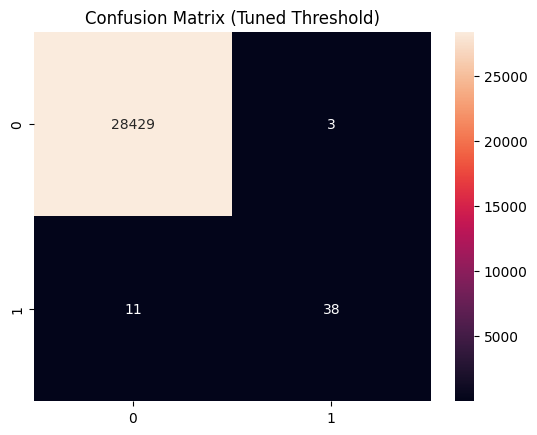

In [81]:
import seaborn as sns

cm = confusion_matrix(y_val, y_pred_tuned)
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix (Tuned Threshold)")
plt.show()

# Risk Scoring Framework

Convert probabilities to risk score

In [82]:
risk_score = (y_proba * 100).round(2)

Create a dataframe

In [83]:
import pandas as pd

risk_df = pd.DataFrame({
    "Fraud_Probability": y_proba,
    "Risk_Score": risk_score
})

risk_df.head()

,Fraud_Probability,Risk_Score
0,0.000058,0.01
1,0.000232,0.02
2,0.000082,0.01
3,0.000064,0.01
4,0.000144,0.01


Assign risk tiers

In [84]:
def assign_risk(score):

    if score <= 30:
        return "Low"
    elif score <= 60:
        return "Medium"
    elif score <= 85:
        return "High"
    else:
        return "Critical"

risk_df["Risk_Level"] = risk_df["Risk_Score"].apply(assign_risk)

In [85]:
def assign_action(level):

    if level == "Low":
        return "Auto-approve"
    elif level == "Medium":
        return "Allow but monitor"
    elif level == "High":
        return "Step-up authentication"
    else:
        return "Auto-decline / analyst review"

risk_df["Recommended_Action"] = risk_df["Risk_Level"].apply(assign_action)

risk_df.head()

,Fraud_Probability,Risk_Score,Risk_Level,Recommended_Action
0,0.000058,0.01,Low,Auto-approve
1,0.000232,0.02,Low,Auto-approve
2,0.000082,0.01,Low,Auto-approve
3,0.000064,0.01,Low,Auto-approve
4,0.000144,0.01,Low,Auto-approve


Risk Score Summary Table

In [86]:
risk_summary = risk_df["Risk_Level"].value_counts().reset_index()
risk_summary.columns = ["Risk_Level", "Transaction_Count"]

risk_summary

,Risk_Level,Transaction_Count
0,Low,28433
1,Critical,42
2,Medium,3
3,High,3


Add Risk Score Distribution

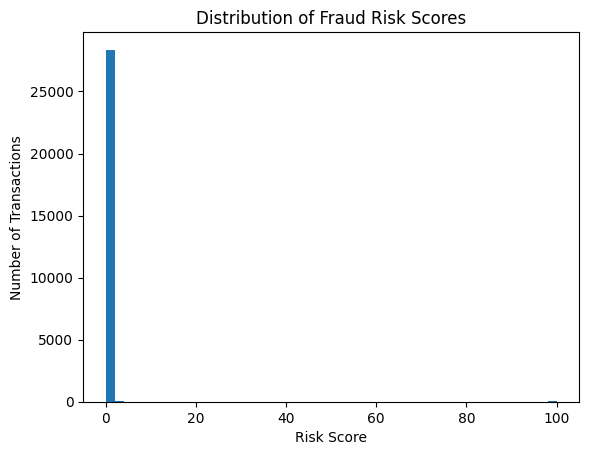

In [87]:
import matplotlib.pyplot as plt

plt.hist(risk_df["Risk_Score"], bins=50)
plt.xlabel("Risk Score")
plt.ylabel("Number of Transactions")
plt.title("Distribution of Fraud Risk Scores")
plt.show()

Risk Level Bar Chart

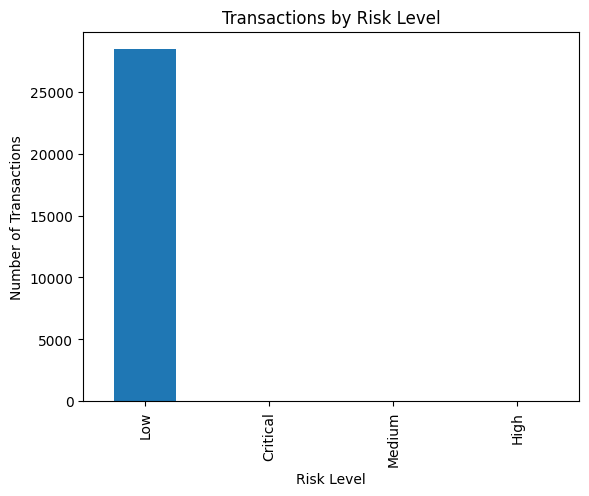

In [88]:
risk_df["Risk_Level"].value_counts().plot(kind="bar")

plt.title("Transactions by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Number of Transactions")
plt.show()